In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data with correct separator (it's a semicolon-separated file)
df = pd.read_csv('..\data\AirQuality.csv', sep=';', decimal=',')

# 2. Drop completely empty columns and rows
df = df.dropna(how='all', axis=1)
df = df.dropna(how='all', axis=0)

# 3. Handle the dataset's specific missing value marker (-200)
# We replace -200 with NaN and then use professional interpolation
df.replace(-200, np.nan, inplace=True)
df = df.interpolate(method='linear') # Fill gaps realistically for time-series

# 4. Feature Engineering: Create a proper DateTime index
# First, fix the time format by replacing dots with colons
df['Time'] = df['Time'].str.replace('.', ':', regex=False)

# Now convert to datetime
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df.set_index('DateTime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

print("Dataset cleaned and indexed. Shape:", df.shape)
df.head()

Dataset cleaned and indexed. Shape: (9357, 13)


C:\Users\Hp\AppData\Local\Temp\ipykernel_13372\4255909419.py:16: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear') # Fill gaps realistically for time-series


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
DateTime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


### Step 2: Exploratory Data Analysis (Correlation)
To scientifically justify feature selection, we compute the **Pearson Correlation Coefficient** ($\rho$) between different pollutants. This helps identify which gases are co-emitted (e.g., from vehicular exhaust) and ensures our model isn't trained on redundant or irrelevant features.

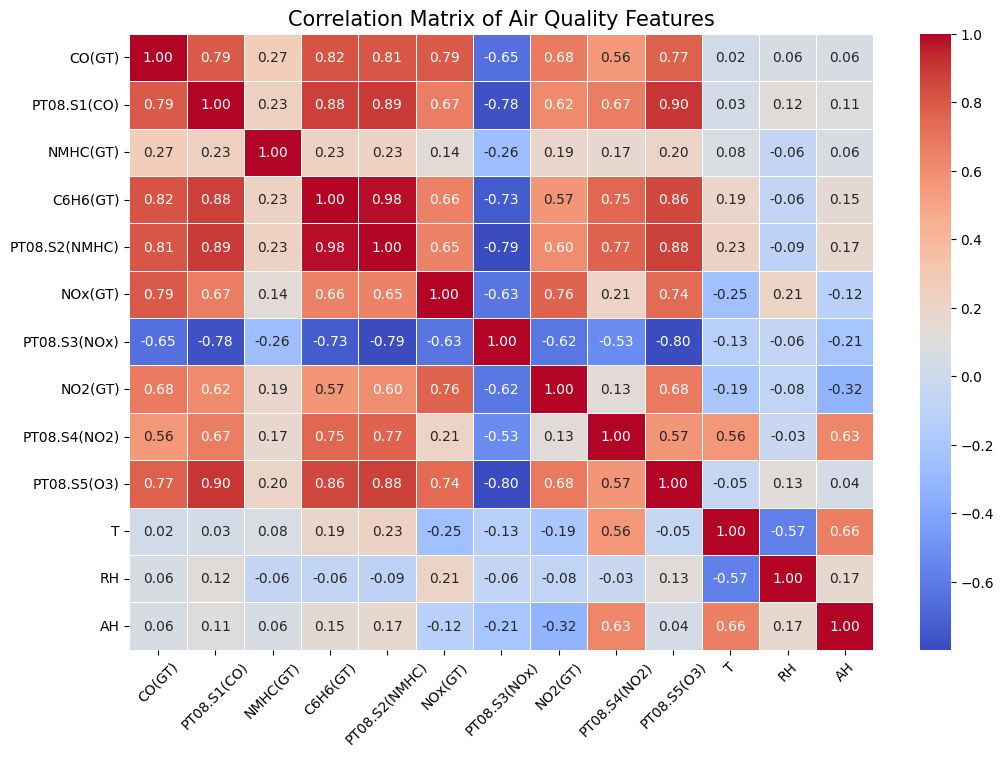

In [2]:
# Calculate Correlation Matrix
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()

# Plot Heatmap with high-level formatting
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Air Quality Features", fontsize=15)
plt.xticks(rotation=45)
plt.show()

# Insight: Features with high correlation (close to 1.0) indicate shared emission sources.

### Step 3: Multi-Stage Pipeline - Anomaly Detection
Before training predictive models, we implement **Isolation Forest**, an unsupervised learning algorithm. 
- **Goal**: Identify sensor malfunctions or extreme pollution events (outliers).
- **Novelty**: By detecting anomalies first, we can create an 'Anomaly-Aware' system that alerts the user when data patterns deviate from the norm, rather than just providing a standard prediction.

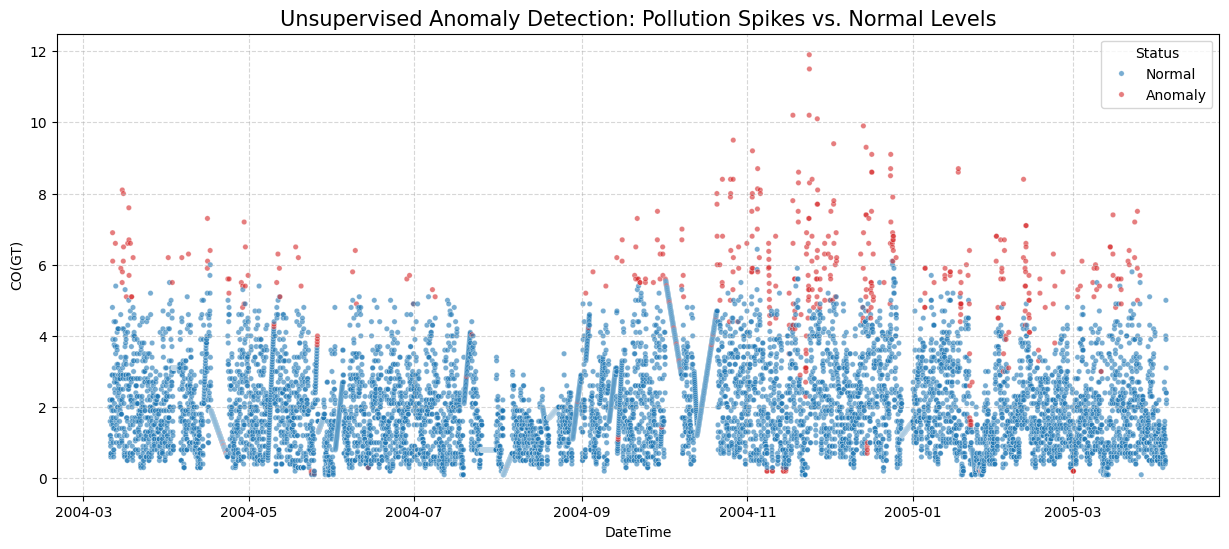

Analysis Complete: Detected 468 anomalous instances.


In [3]:
from sklearn.ensemble import IsolationForest

# Select key pollutants for detection
features = ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

# Initialize model: contamination=0.05 assumes 5% of the data is anomalous
iso_model = IsolationForest(contamination=0.05, random_state=42)
df['anomaly_label'] = iso_model.fit_predict(df[features])

# Map labels for clarity: 1 = Normal, -1 = Anomaly
df['Status'] = df['anomaly_label'].map({1: 'Normal', -1: 'Anomaly'})

# Visualization of Anomalies over Time
plt.figure(figsize=(15, 6))
sns.scatterplot(data=df.reset_index(), x='DateTime', y='CO(GT)', 
                hue='Status', palette={'Normal': 'tab:blue', 'Anomaly': 'tab:red'}, 
                s=15, alpha=0.6)
plt.title("Unsupervised Anomaly Detection: Pollution Spikes vs. Normal Levels", fontsize=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Analysis Complete: Detected {len(df[df['Status'] == 'Anomaly'])} anomalous instances.")

### Step 4: Predictive Analytics & High-Level Novelty
This stage involves two distinct modeling approaches:
1. **Linear Regression**: Used to predict the target pollutant concentration based on sensor readings.
2. **Cox Proportional Hazards Model (Survival Analysis)**: This is the project's core novelty. Instead of just predicting a value, we model the **'Time-to-Event'**. 
   - **Event**: A pollution spike (e.g., CO > 4.0).
   - **Goal**: Predict the probability that a hazardous event will occur within the next $n$ hours.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn import set_config
import joblib
import os

# 1. Prepare Data
X_reg = df[['PT08.S1(CO)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH']]
y_reg = df['CO(GT)']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 2. Define the Multi-Stage Pipeline
# We enable visual display so you can see the diagram in the notebook
set_config(display='diagram')

reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),       # Step 1: Normalize sensor scales
    ('regressor', LinearRegression())   # Step 2: Predict CO level
])

# 3. Train and Evaluate
reg_pipeline.fit(X_train, y_train)

# Show the pipeline architecture visually in your notebook
display(reg_pipeline)

y_pred = reg_pipeline.predict(X_test)
print(f"Pipeline Regression R2 Score: {r2_score(y_test, y_pred):.4f}")

# 4. Save Models for Backend Use
model_dir = os.path.join('..', 'models')
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the entire Pipeline object (not just the model)
joblib.dump(reg_pipeline, os.path.join(model_dir, 'reg_pipeline.pkl'))
joblib.dump(iso_model, os.path.join(model_dir, 'anomaly_model.pkl'))

print(f"Pipeline and Anomaly model saved in: {os.path.abspath(model_dir)}")

,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


Pipeline Regression R2 Score: 0.8054
Pipeline and Anomaly model saved in: d:\Programming\Airlytics\models


### Step 5.1 Regression Model Evaluation
We evaluate the Linear Regression model using multiple error metrics to understand its predictive accuracy and error distribution.
- **MAE/MSE/RMSE**: To quantify the magnitude of prediction errors.
- **Residual Analysis**: To ensure errors are randomly distributed (Homoscedasticity), which is a core requirement for a valid regression model.

--- Regression Performance Metrics ---
Mean Absolute Error (MAE): 0.4370
Mean Squared Error (MSE): 0.4241
Root Mean Squared Error (RMSE): 0.6512
R-Squared (R2) Score: 0.8054


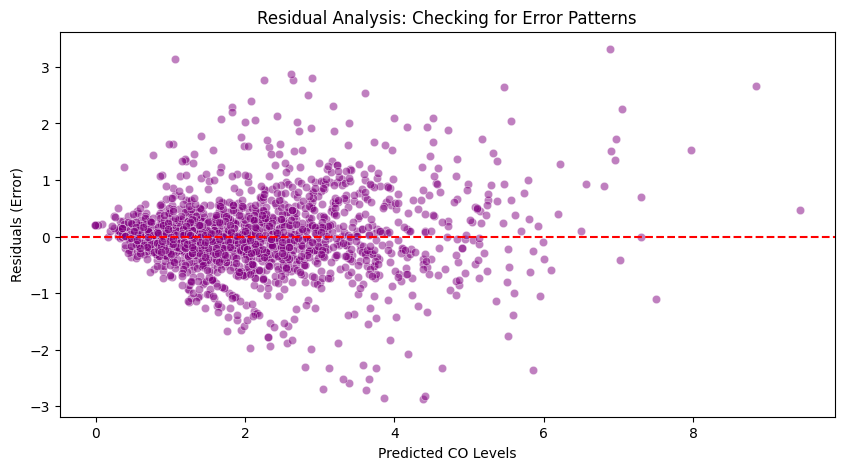

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Calculate Extended Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Regression Performance Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-Squared (R2) Score: {r2:.4f}")

# 2. Residual Plot
plt.figure(figsize=(10, 5))
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals, color='purple', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted CO Levels')
plt.ylabel('Residuals (Error)')
plt.title('Residual Analysis: Checking for Error Patterns')
plt.show()

### Step 5.2 Anomaly Detection Evaluation (Isolation Forest)
Since Isolation Forest is unsupervised, we evaluate it by inspecting the **Anomaly Score Distribution**. 
- Lower scores indicate more "anomalous" observations. 
- We also check the count to ensure the 5% contamination threshold ($0.05$) aligns with the dataset's variance.

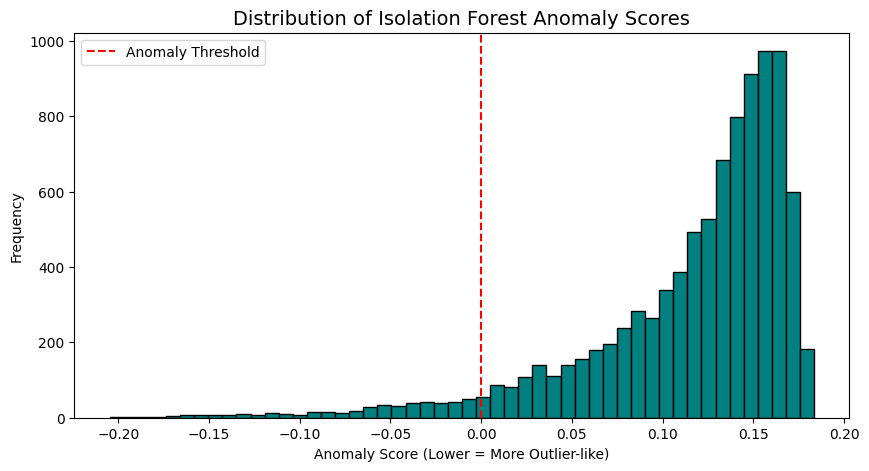

--- Anomaly Detection Summary ---
Total Data Points: 9357
Anomalies Detected: 468 (5.00%)


In [6]:
# 1. Use ONLY the features the Isolation Forest was trained on
iso_features = ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

# 2. Get Anomaly Scores (The lower the score, the more anomalous)
# Note: Use df[iso_features] instead of X_reg
anomaly_scores = iso_model.decision_function(df[iso_features])

plt.figure(figsize=(10, 5))
plt.hist(anomaly_scores, bins=50, color='teal', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Anomaly Threshold')
plt.title("Distribution of Isolation Forest Anomaly Scores", fontsize=14)
plt.xlabel("Anomaly Score (Lower = More Outlier-like)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 3. Summary of Findings
# Note: Ensure the column name matches what you used in Step 3 (anomaly_label)
total_anomalies = (df['anomaly_label'] == -1).sum()
print(f"--- Anomaly Detection Summary ---")
print(f"Total Data Points: {len(df)}")
print(f"Anomalies Detected: {total_anomalies} ({ (total_anomalies/len(df))*100:.2f}%)")

### Step 5.3 Model Stability Check (K-Fold Cross-Validation)
To prove the model is high-level, we use **5-Fold Cross-Validation**. This ensures our R2 score isn't a result of "getting lucky" with a specific train-test split.

In [8]:
from sklearn.model_selection import cross_val_score

# Perform 5-Fold Cross Validation on the entire feature set
cv_scores = cross_val_score(reg_pipeline, X_reg, y_reg, cv=5, scoring='r2')

print("--- Cross-Validation Results (R2) ---")
print(f"Individual Fold Scores: {cv_scores}")
print(f"Mean CV R2 Score: {cv_scores.mean():.4f}")
print(f"Stability (Std Dev): {cv_scores.std():.4f}")

--- Cross-Validation Results (R2) ---
Individual Fold Scores: [0.49946474 0.64867209 0.69860757 0.84015332 0.64091008]
Mean CV R2 Score: 0.6656
Stability (Std Dev): 0.1096


### Step 6: High-Level Novelty - Cox Proportional Hazards
Standard models predict 'How much' pollution there is. This model predicts **'When'** a dangerous event will occur.
- **Event**: CO levels exceeding a safety threshold (> 4.5 mg/m³).
- **Duration**: The time elapsed (in hours) since the start of the observation period.
- **Goal**: To understand how features like NO2 and Humidity impact the 'hazard' (risk) of a pollution spike.

In [9]:
from lifelines import CoxPHFitter

# 1. Prepare data for Cox Regression
# We create a 'Hazard' dataset with an Event indicator
df_cox = df[['PT08.S1(CO)', 'NO2(GT)', 'T', 'RH', 'CO(GT)']].copy()
df_cox['event'] = (df_cox['CO(GT)'] > 4.5).astype(int) # 1 if spike, 0 if normal
df_cox['duration'] = np.arange(len(df_cox)) # Time steps

# 2. Fit the Cox Model
cph = CoxPHFitter()
cph.fit(df_cox.drop('CO(GT)', axis=1), duration_col='duration', event_col='event')

# 3. Output the Hazard Ratios with HTML Formatting
print("--- Cox Regression Results (Statistical Summary) ---")
# Use cph.summary to get the dataframe, or just cph for the stylized output
display(cph.summary) 

# 4. Save the Cox model
import os
joblib.dump(cph, os.path.join(model_dir, 'cox_model.pkl'))
print(f"\nCox model saved successfully in {model_dir}")

--- Cox Regression Results (Statistical Summary) ---


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
PT08.S1(CO),0.005224,1.005238,0.000243,0.004749,0.005700,1.004760,1.005716,0.0,21.526435,8.805297e-103,339.020222
NO2(GT),0.008088,1.008121,0.001305,0.005531,0.010646,1.005546,1.010702,0.0,6.199151,5.676846e-10,30.714191
T,0.132957,1.142201,0.010835,0.111720,0.154194,1.118200,1.166717,0.0,12.270506,1.304355e-34,112.562218
RH,0.027783,1.028173,0.004550,0.018866,0.036700,1.019045,1.037382,0.0,6.106851,1.016158e-09,29.874228



Cox model saved successfully in ..\models


### 5.4 Regression Accuracy: Actual vs. Predicted Values
To visualize the real-world performance of our **Linear Regression Pipeline**, we plot the actual CO concentration against our model's predictions over a specific time window. This allows us to see how well the model captures daily pollution cycles and sudden spikes.

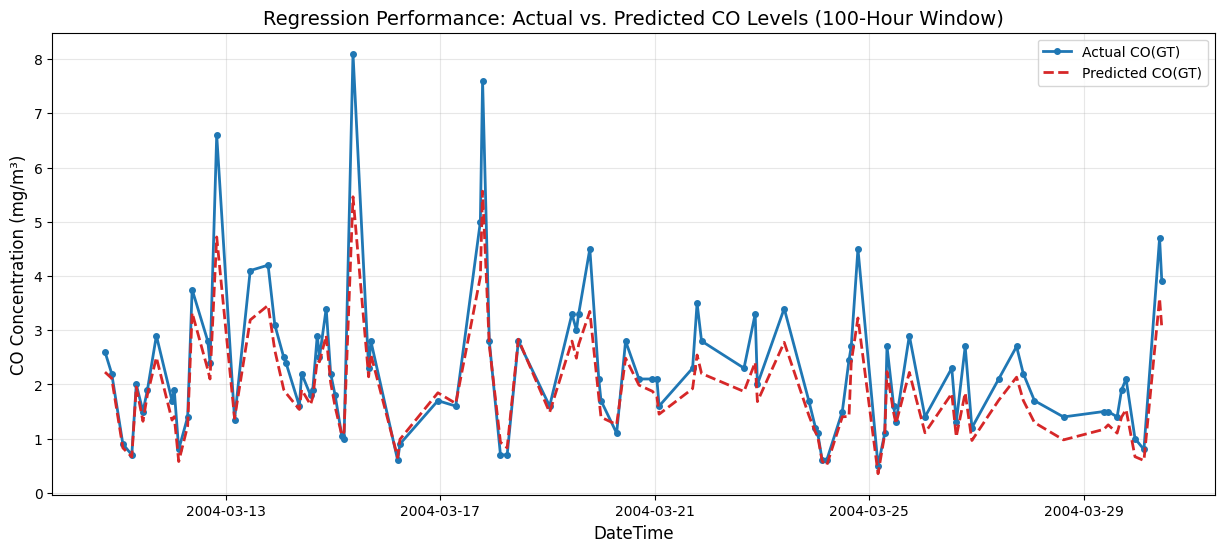

Visualization complete. R2 Score remains: 0.8054


In [10]:
# 1. Prepare data for plotting (Sort by index to keep time sequence)
test_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)
test_results = test_results.sort_index()

# 2. Plotting a 100-hour window for clarity
plt.figure(figsize=(15, 6))
plt.plot(test_results.index[:100], test_results['Actual'][:100], 
         label='Actual CO(GT)', color='tab:blue', linewidth=2, marker='o', markersize=4)
plt.plot(test_results.index[:100], test_results['Predicted'][:100], 
         label='Predicted CO(GT)', color='tab:red', linestyle='--', linewidth=2)

# 3. Formatting
plt.title("Regression Performance: Actual vs. Predicted CO Levels (100-Hour Window)", fontsize=14)
plt.xlabel("DateTime", fontsize=12)
plt.ylabel("CO Concentration (mg/m³)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Visualization complete. R2 Score remains: {r2_score(y_test, y_pred):.4f}")